In [1]:
import os
import numpy as np
import rerun as rr
import cv2
from tqdm.notebook import tqdm
import torch
from REIN import REIN
import pandas as pd
from torch.profiler import profile, record_function, ProfilerActivity
from torchvision.utils import save_image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from numpy import genfromtxt
from scipy.spatial.transform import Rotation as R
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import faiss
import open3d as o3d

torch.cuda.is_available()

/mnt/sdb1/mipt_place_recognition_data/miniconda3/envs/opr/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sdb1/mipt_place_recognition_data/miniconda3/envs/opr/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


True

In [2]:
base_dir = "/mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam"
maps = ['AIRI_slam_1', "AIRI_slam_2", "AIRI_slam_3"]

# Extract query and db points

In [2]:
poses_1 = pd.read_csv('/mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam/AIRI_slam_1/keyframe_map/poses.csv')
poses_2 = pd.read_csv('/mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam/AIRI_slam_2/keyframe_map/poses.csv')
poses_3 = pd.read_csv('/mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam/AIRI_slam_3/keyframe_map/poses.csv')

In [3]:
poses = [poses_1, poses_2, poses_3]
for i, _ in enumerate(poses):
    poses[i] = poses[i].reset_index().rename(columns={'index': 'lidar_ts'})
    poses[i]['lidar_ts'] = poses[i]['lidar_ts'].astype(str) + f'm{i+1}'

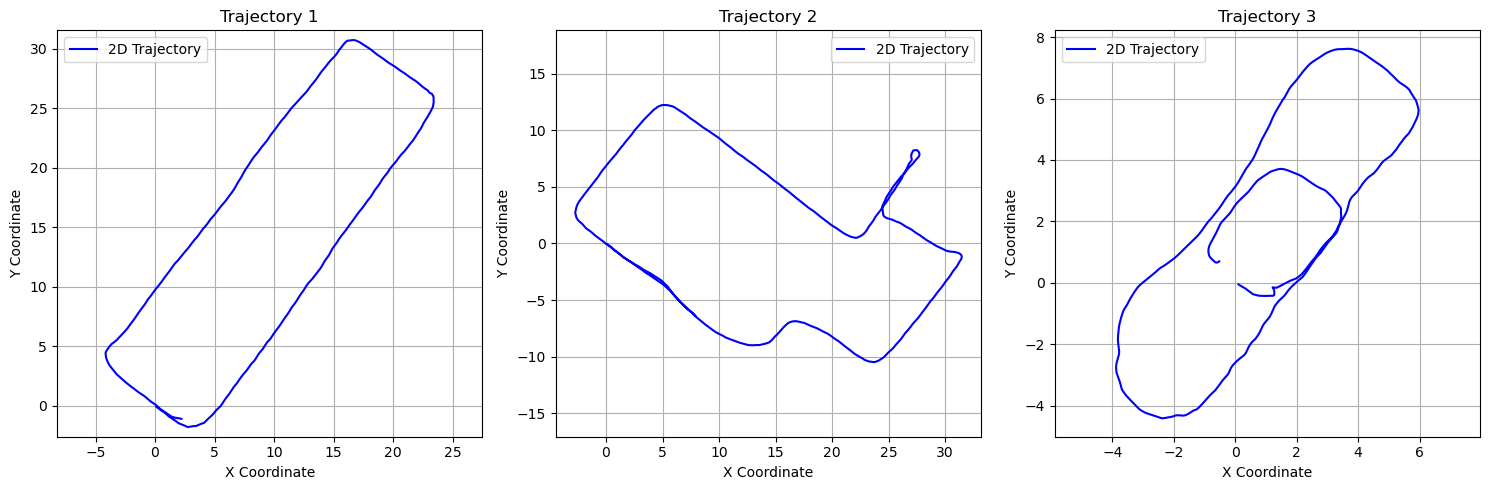

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

traj_dfs = [poses_1, poses_2, poses_3]
titles = ['Trajectory 1', 'Trajectory 2', 'Trajectory 3']

for i, (df, title) in enumerate(zip(traj_dfs, titles)):
    ax = axes[i]
    ax.plot(df['px'], df['py'], label='2D Trajectory', color='blue')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    ax.axis('equal')

plt.tight_layout()
plt.show()

In [36]:
def pose_to_matrix(tx, ty, tz, qx, qy, qz, qw):
    rot = R.from_quat([qx, qy, qz, qw]).as_matrix()
    T = np.eye(4)
    T[:3, :3] = rot
    T[:3, 3] = [tx, ty, tz]
    return T

def matrix_to_pose(T):
    tx, ty, tz = T[:3, 3]
    rot = R.from_matrix(T[:3, :3])
    qx, qy, qz, qw = rot.as_quat()
    return tx, ty, tz, qx, qy, qz, qw

def transform_poses(df, T_map_i_to_1):
    new_poses = []
    for _, row in df.iterrows():
        T_pose = pose_to_matrix(row.px, row.py, row.pz, row.qx, row.qy, row.qz, row.qw)
        T_transformed = T_map_i_to_1 @ T_pose
        new_poses.append(matrix_to_pose(T_transformed))
    df[['px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw']] = pd.DataFrame(new_poses, index=df.index)
    return df

df1 = poses[0]
df2 = poses[1]
df3 = poses[2]

T_2_1 = np.array([
    [ 0.999112457631, -0.039503143996,  0.014621854211,  3.984303382076],
    [ 0.039680493701,  0.999139825710, -0.012044380408, -9.931692551976],
    [-0.014133485974,  0.012613892904,  0.999820551039, -0.119426156108],
    [ 0.000000000000,  0.000000000000,  0.000000000000,  1.000000000000],
])

T_3_1 = np.array([
    [ 0.037523581010,  0.999220245110,  0.012283429097,  9.583066309331],
    [-0.999233230946,  0.037655887564, -0.010723073448, -16.919906575331],
    [-0.011177255504, -0.011871642429,  0.999867057696, -0.340373435740],
    [ 0.000000000000,  0.000000000000,  0.000000000000,  1.000000000000],
])

df2_transformed = transform_poses(df2.copy(), T_2_1)
df3_transformed = transform_poses(df3.copy(), T_3_1)

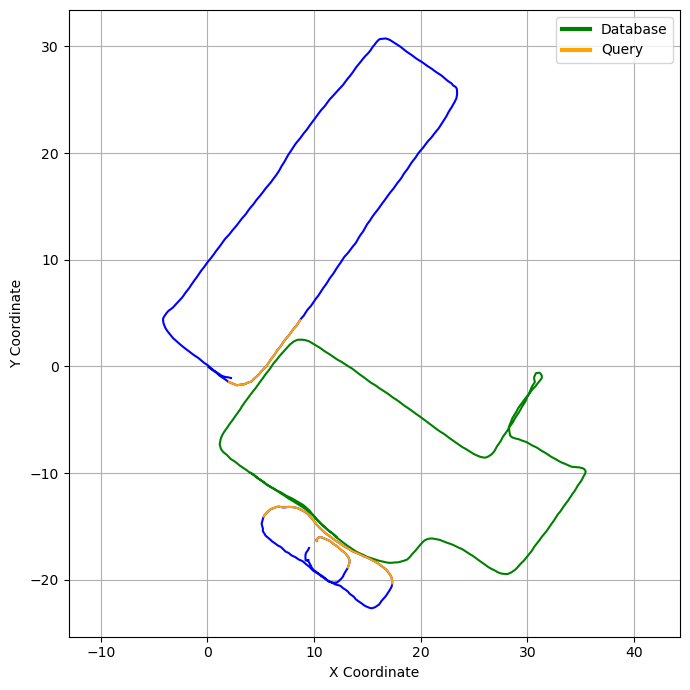

In [40]:
from matplotlib.lines import Line2D

db_dfs = []
query_dfs = []

plt.figure(figsize=(7, 7))

# plot tracks 
plt.plot(df1['px'], df1['py'], color='blue')
plt.plot(df2_transformed['px'], df2_transformed['py'], color='green')
plt.plot(df3_transformed['px'], df3_transformed['py'], color='blue')


# extract and plot database timestamps
query_dfs.append(df1[(df1['# ts'] >= 1734015985.046226 + 4) & (df1['# ts'] <= 1734016005.5460029 - 1)])
query_dfs.append(df3_transformed[(df3_transformed['# ts'] >= df3_transformed['# ts'].max() - 10)])
query_dfs.append(df3_transformed[(df3_transformed['# ts'] >= df3_transformed['# ts'].median() - 15) 
    & (df3_transformed['# ts'] <= df3_transformed['# ts'].median() + 8)])

plt.plot(query_dfs[0]['px'], query_dfs[0]['py'], color='orange')
plt.plot(query_dfs[1]['px'], query_dfs[1]['py'], color='orange')
plt.plot(query_dfs[2]['px'], query_dfs[2]['py'], color='orange')


legend_elements = [
    Line2D([0], [0], color='green', lw=3, label='Database'),
    Line2D([0], [0], color='orange', lw=3, label='Query'),
]

plt.legend(handles=legend_elements, loc='upper right')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [41]:
db_dfs = df2_transformed
query_dfs = pd.concat(query_dfs).reset_index(drop=True)

In [42]:
distance_threshold = 0.2 # meters
angle_threshold = np.deg2rad(30) #radians

filtered_indices_per_pose = []
filtered_indices = [0]
for i in range(1, len(db_dfs)):
    prev_pose = db_dfs.iloc[filtered_indices[-1]][['px', 'py', 'pz', 'qz', 'qy', 'qz', 'qw']].values
    curr_pose = db_dfs.iloc[i][['px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw']].values

    distance = np.linalg.norm(curr_pose[:3] -  prev_pose[:3])

    dot_product = np.dot(curr_pose[3:], prev_pose[3:])
    angle_rad = 2 * np.arccos(np.clip(dot_product, -1.0, 1.0))

    if distance > distance_threshold or angle_rad > angle_threshold:
        filtered_indices.append(i)
filtered_indices_per_pose.append(filtered_indices)
print(f"Filtered poses count: {len(filtered_indices)} out of {len(db_dfs)}")

Filtered poses count: 468 out of 1395


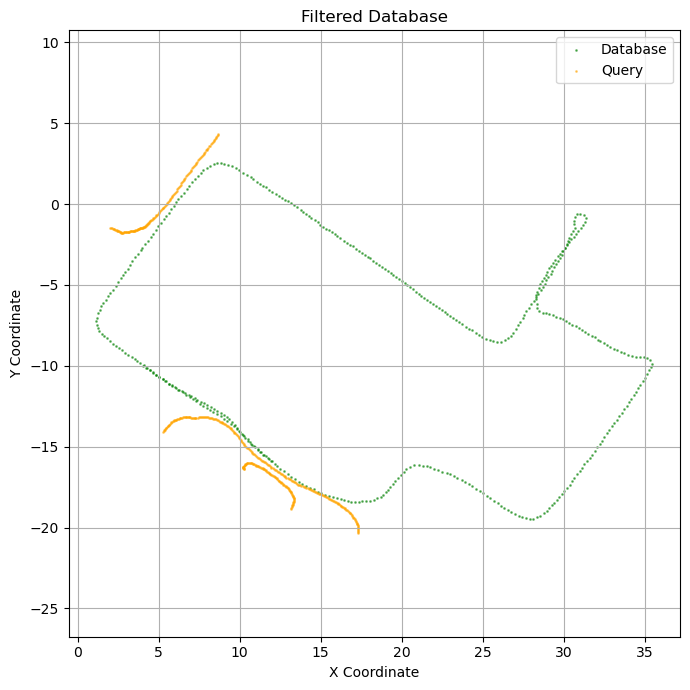

In [43]:
plt.figure(figsize=(7, 7)) 

df_db = db_dfs.iloc[filtered_indices]

plt.scatter(df_db['px'], df_db['py'], color='green', alpha=0.5, label='Database', s=1)
plt.scatter(query_dfs['px'], query_dfs['py'], label='Query', color='orange', alpha=0.5, s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Filtered Database')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [46]:
db_csv_path = os.path.join(base_dir, 'db_lidar_poses_full.csv')
query_csv_path = os.path.join(base_dir, 'query_lidar_poses_full.csv')

df_db.to_csv(db_csv_path, index=False)
print(f"Filtered database saved to {db_csv_path}")
print("-"*60)
query_dfs.to_csv(query_csv_path, index=False)
print(f"Query frames saved to {query_csv_path}")


Filtered database saved to /mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam/db_lidar_poses_full.csv
------------------------------------------------------------
Query frames saved to /mnt/sdb1/mipt_place_recognition_data/2024-12-14-AIRI-dataset/processed-data/slam/slam/query_lidar_poses_full.csv


# Aggregate points to construct richer point clouds

In [3]:
def load_pcd_points(pcd_path):
    pcd = o3d.io.read_point_cloud(pcd_path)
    return np.asarray(pcd.points)  # (N, 3)

In [78]:
resolutions = [0.1, 0.2, 0.4]
res2border = {0.1: 20, 0.2: 30, 0.4: 40}
res2dir = {
    0.1: "keyframe_map_voxelizatinon_0.1",
    0.2: "keyframe_map_voxelizatinon_0.2",
    0.4: "keyframe_map_voxelizatinon_0.3",
}
# res2voxelsize = {0.4: 0.4, 0.1: 0.05, 0.2: 0.2}
res2voxelsize = {
    0.4: {
        1: 0.4, 2: 0.4, 3: 0.4, 4: 0.4
    }, 0.1: {
        1: 0.1, 2: 0.1, 3: 0.13, 4: 0.15
    }, 0.2: {
        1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2
    }
}

In [79]:
def getBEV_torch(all_points, val=40, resolution=0.2, device='cpu'):
    """
    all_points: torch.Tensor of shape (N, 3) on the specified device
    Returns: BEV image as torch.Tensor (H, W) on the same device
    """
    max_val = val
    min_val = -val
    x_min, y_min = min_val, min_val
    x_max, y_max = max_val, max_val

    mask = (all_points[:,0].abs() < max_val) & (all_points[:,1].abs() < max_val) & (all_points[:,2].abs() < max_val)
    all_points = all_points[mask]

    x_min_ind = torch.floor(torch.tensor(x_min/resolution)).int()
    x_max_ind = torch.floor(torch.tensor(x_max/resolution)).int()
    y_min_ind = torch.floor(torch.tensor(y_min/resolution)).int()
    y_max_ind = torch.floor(torch.tensor(y_max/resolution)).int()
    x_num = x_max_ind - x_min_ind + 1
    y_num = y_max_ind - y_min_ind + 1

    mat_global_image = torch.zeros((y_num, x_num), dtype=torch.uint8, device=device)

    x_ind = x_max_ind - torch.floor(all_points[:, 1] / resolution).int()
    y_ind = y_max_ind - torch.floor(all_points[:, 0] / resolution).int()

    valid = (x_ind >= 0) & (x_ind < x_num) & (y_ind >= 0) & (y_ind < y_num)
    x_ind = x_ind[valid]
    y_ind = y_ind[valid]

    flat_indices = y_ind * x_num + x_ind
    bincount = torch.bincount(flat_indices, minlength=y_num * x_num)
    bincount = bincount.clamp(max=10).reshape(y_num, x_num)

    mat_global_image = bincount * 10
    mat_global_image = torch.clamp(mat_global_image, max=255)
    if mat_global_image.max() > 0:
        mat_global_image = mat_global_image.float() / mat_global_image.max() * 255
    else:
        mat_global_image = mat_global_image.float()
    mat_global_image = mat_global_image.to(torch.uint8)

    return mat_global_image.detach().cpu()

In [80]:
thres = 4
global_step = 0
for res in tqdm(resolutions):
    bev_dir = os.path.join(base_dir, f'bev_{res2dir[res]}_res={res}_thres={thres}')
    os.makedirs(bev_dir, exist_ok=True)
    
    for i, slam_map in enumerate(maps):
        
        lidar_dir = os.path.join(base_dir, slam_map, res2dir[res], 'scans')
        lidar_files = sorted([f for f in os.listdir(lidar_dir) if f.endswith('.pcd')])
        poses = pd.read_csv(os.path.join(base_dir, slam_map, res2dir[res], 'poses.csv'))
        
        all_points = []
        for idx, filename in tqdm(enumerate(lidar_files), leave=False, desc=f"Collecting points in map_{i + 1} for res={res}"):
            full_lidar_path = os.path.join(lidar_dir, filename)
            pcs_np = load_pcd_points(full_lidar_path)
        
            if pcs_np.shape[1] > 3:  
                pcs_np = pcs_np[:, :3]

            pose = poses.iloc[idx]
            t = pose[['px', 'py', 'pz']].values
            q = pose[['qx', 'qy', 'qz', 'qw']].values

            R_mat = R.from_quat(q).as_matrix()
            pcs_global = (R_mat @ pcs_np.T).T + t
            
            all_points.append(pcs_global)
    

        agg_buffer = []
        pose_buffer = []
        ref_pose = poses.iloc[0][['px', 'py', 'pz']].values
        for j in tqdm(range(len(all_points)), leave=False, desc=f"Aggregating points for map_{i + 1} for res={res}"):
            cur_pose = poses.iloc[j][['px', 'py', 'pz']].values
            agg_buffer.append(all_points[j])
            pose_buffer.append(cur_pose)
            
            while np.linalg.norm(cur_pose - pose_buffer[0]) > thres:
                agg_buffer.pop(0)
                pose_buffer.pop(0)
            
            agg_points = np.concatenate(agg_buffer, axis=0)

            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(agg_points)
            if thres != 0: downsampled_pcd = pcd.voxel_down_sample(voxel_size=res2voxelsize[res][thres])
            else: downsampled_pcd = pcd

            down_points = np.asarray(downsampled_pcd.points)
            
            centered_points = down_points - cur_pose

            pcs_tensor = torch.from_numpy(centered_points).float().cuda()
            bev = getBEV_torch(pcs_tensor, resolution=res, val=res2border[res], device='cuda')
            bev = bev / 255.
       
            save_path = os.path.join(bev_dir, f"{j}m{i + 1}.png")
            save_image(bev.unsqueeze(0).repeat(3, 1, 1), save_path)

  0%|          | 0/3 [00:00<?, ?it/s]

Aggregating points for map_1 for res=0.1:   0%|          | 0/1074 [00:00<?, ?it/s]

Aggregating points for map_2 for res=0.1:   0%|          | 0/1395 [00:00<?, ?it/s]

Aggregating points for map_3 for res=0.1:   0%|          | 0/831 [00:00<?, ?it/s]

Aggregating points for map_1 for res=0.2:   0%|          | 0/1074 [00:00<?, ?it/s]

Aggregating points for map_2 for res=0.2:   0%|          | 0/1395 [00:00<?, ?it/s]

Aggregating points for map_3 for res=0.2:   0%|          | 0/831 [00:00<?, ?it/s]

Aggregating points for map_1 for res=0.4:   0%|          | 0/1074 [00:00<?, ?it/s]

Aggregating points for map_2 for res=0.4:   0%|          | 0/1395 [00:00<?, ?it/s]

Aggregating points for map_3 for res=0.4:   0%|          | 0/831 [00:00<?, ?it/s]

# Compute Metrics

In [51]:
class AIRIDataset(Dataset):
    def __init__(self, base_dir, resolution, lidar_pose_filename, thres):
        bev_dir = os.path.join(
            base_dir,
            f"bev_" + res2dir[resolution] + f"_res={resolution:.1f}_thres={thres}"
        )
        csv_path = os.path.join(base_dir, lidar_pose_filename)

        self.bev_dir = bev_dir
        self.lidar_pose_df = pd.read_csv(csv_path)

        self.img_files = {
            f.split('.')[0] : os.path.join(self.bev_dir, f)
            for f in os.listdir(self.bev_dir) if f.endswith(".png")
        }

    def __getitem__(self, index):
        row = self.lidar_pose_df.iloc[index]
        img = cv2.imread(self.img_files[row['lidar_ts']], cv2.IMREAD_GRAYSCALE) / 255.0
        img = img[np.newaxis, :, :].repeat(3, 0)
        return torch.tensor(img, dtype=torch.float32), row[['px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw']].values.astype(float)

    def __len__(self):
        return len(self.lidar_pose_df)


In [52]:
device = 'cuda'
model = REIN()
checkpoint = torch.load(
    '/home/mipt_2025/nabiev/place_recognition/BEVPlace2/runs/Aug08_10-17-29/model_best.pth.tar',
    map_location=lambda storage,
    loc: storage,
    weights_only=False
)
model.load_state_dict(checkpoint['state_dict'])
model = model.to(device)
model.eval();

/mnt/sdb1/mipt_place_recognition_data/miniconda3/envs/opr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/sdb1/mipt_place_recognition_data/miniconda3/envs/opr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [81]:
def get_metrics(gt_thres, base_dir, model, device, diameter):
    res_list = [0.1, 0.2, 0.4]
    k = 5
    recalls_at_1 = []
    recalls_at_5 = []
    trans_errors = []
    rot_errors = []

    print(f"\n====== GT threshold: {gt_thres} ======\n")

    for res in res_list:
        print(f"\n--- Resolution: {res} ---")

        db_set = AIRIDataset(base_dir, res, 'db_lidar_poses_full.csv', diameter)
        db_loader = DataLoader(db_set, batch_size=1)
        db_global_descs = []

        model.eval()
        with torch.no_grad():
            for img, _ in db_loader:
                img = img.to(device)
                _, _, global_desc = model(img)
                db_global_descs.append(global_desc.cpu().numpy())
        db_global_descs = np.concatenate(db_global_descs, axis=0)

        faiss_index = faiss.IndexFlatL2(db_global_descs.shape[1])
        faiss_index.add(db_global_descs)

        query_set = AIRIDataset(base_dir, res, 'query_lidar_poses_full.csv', diameter)
        query_loader = DataLoader(query_set, batch_size=1, shuffle=False)
        query_global_descs = []

        with torch.no_grad():
            for img, _ in query_loader:
                img = img.to(device)
                _, _, global_desc = model(img)
                query_global_descs.append(global_desc.cpu().numpy())
        query_global_descs = np.concatenate(query_global_descs, axis=0)

        _, predictions = faiss_index.search(query_global_descs, k=k)

        recalls_1, recalls_5 = 0, 0
        trans_errs = []
        rot_errs = []

        for q_idx, pred_list in enumerate(predictions):
            _, q_pose = query_set[q_idx]
            q_pose, q_quat = q_pose[:3], q_pose[3:]

            match_1, match_5 = False, False
            best_trans_err, best_rot_err = float('inf'), float('inf')

            for rank, db_idx in enumerate(pred_list):
                _, db_pose = db_set[db_idx]
                db_pose, db_quat = db_pose[:3], db_pose[3:]

                trans_err = np.linalg.norm(q_pose - db_pose)
                rot_err = 2 * np.arccos(np.clip(np.abs(np.dot(q_quat, db_quat)), -1.0, 1.0))

                best_trans_err = min(best_trans_err, trans_err)
                best_rot_err = min(best_rot_err, rot_err)

                if trans_err < gt_thres:
                    if rank == 0:
                        match_1 = True
                    match_5 = True

            trans_errs.append(best_trans_err)
            rot_errs.append(best_rot_err)
            if match_1:
                recalls_1 += 1
            if match_5:
                recalls_5 += 1

        total = len(query_set)
        print(f"Recall@1: {recalls_1 / total}")
        print(f"Recall@5: {recalls_5 / total}")
        print(f"Mean Translation Error: {np.mean(trans_errs)} m")
        print(f"Mean Rotation Error: {np.mean(rot_errs)} rad")

        recalls_at_1.append(recalls_1 / total)
        recalls_at_5.append(recalls_5 / total)
        trans_errors.append(np.mean(trans_errs))
        rot_errors.append(np.mean(rot_errs))

    return recalls_at_1, recalls_at_5, trans_errors, rot_errors

In [82]:
gt_list = [0.5, 0.7, 1, 2, 3, 4, 5]
diameters = [0, 1, 2, 3, 4]
res_per_diam_per_gt = []
for diam in tqdm(diameters):
    ress = []
    for gt_thres in tqdm(gt_list):
        results = get_metrics(gt_thres, base_dir, model, device, diam)
        ress.append(results)
    res_per_diam_per_gt.append(ress)
    print("="*50)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]


====== GT threshold: 0.5 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.008247422680412371
Mean Translation Error: 12.305498160313737 m
Mean Rotation Error: 0.9209628593271395 rad

--- Resolution: 0.2 ---
Recall@1: 0.0
Recall@5: 0.01443298969072165
Mean Translation Error: 10.3038981482988 m
Mean Rotation Error: 0.8939015332290136 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.010309278350515464
Mean Translation Error: 8.100938769740711 m
Mean Rotation Error: 1.315366769227013 rad

====== GT threshold: 0.7 ======


--- Resolution: 0.1 ---
Recall@1: 0.002061855670103093
Recall@5: 0.016494845360824743
Mean Translation Error: 12.305498160313737 m
Mean Rotation Error: 0.9209628593271395 rad

--- Resolution: 0.2 ---
Recall@1: 0.0
Recall@5: 0.030927835051546393
Mean Translation Error: 10.3038981482988 m
Mean Rotation Error: 0.8939015332290136 rad

--- Resolution: 0.4 ---
Recall@1: 0.004123711340206186
Recall@5: 0.032989690721649485
Mean Translation Error: 8.10093876974071

  0%|          | 0/7 [00:00<?, ?it/s]


====== GT threshold: 0.5 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.0
Mean Translation Error: 10.429384811761903 m
Mean Rotation Error: 1.3159801305331067 rad

--- Resolution: 0.2 ---
Recall@1: 0.0
Recall@5: 0.004123711340206186
Mean Translation Error: 8.937402748460316 m
Mean Rotation Error: 1.4543469044772943 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.0
Mean Translation Error: 8.093732813644905 m
Mean Rotation Error: 1.2708668226024094 rad

====== GT threshold: 0.7 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.012371134020618556
Mean Translation Error: 10.429384811761903 m
Mean Rotation Error: 1.3159801305331067 rad

--- Resolution: 0.2 ---
Recall@1: 0.006185567010309278
Recall@5: 0.026804123711340205
Mean Translation Error: 8.937402748460316 m
Mean Rotation Error: 1.4543469044772943 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.0
Mean Translation Error: 8.093732813644905 m
Mean Rotation Error: 1.2708668226024094 rad

====== GT thres

...


====== GT threshold: 0.5 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.002061855670103093
Mean Translation Error: 8.648681098204847 m
Mean Rotation Error: 1.5854771455596908 rad

--- Resolution: 0.2 ---
Recall@1: 0.0
Recall@5: 0.026804123711340205
Mean Translation Error: 6.976351783368462 m
Mean Rotation Error: 1.4612521182034475 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.012371134020618556
Mean Translation Error: 7.733858266466703 m
Mean Rotation Error: 1.1514613093302324 rad

====== GT threshold: 0.7 ======


--- Resolution: 0.1 ---
Recall@1: 0.002061855670103093
Recall@5: 0.0288659793814433
Mean Translation Error: 8.648681098204847 m
Mean Rotation Error: 1.5854771455596908 rad

--- Resolution: 0.2 ---
Recall@1: 0.008247422680412371
Recall@5: 0.041237113402061855
Mean Translation Error: 6.976351783368462 m
Mean Rotation Error: 1.4612521182034475 rad

--- Resolution: 0.4 ---
Recall@1: 0.002061855670103093
Recall@5: 0.020618556701030927
Mean Translation Error:

  0%|          | 0/7 [00:00<?, ?it/s]


====== GT threshold: 0.5 ======


--- Resolution: 0.1 ---
Recall@1: 0.002061855670103093
Recall@5: 0.03505154639175258
Mean Translation Error: 9.077954247119926 m
Mean Rotation Error: 1.4669888109467712 rad

--- Resolution: 0.2 ---
Recall@1: 0.012371134020618556
Recall@5: 0.032989690721649485
Mean Translation Error: 7.439762807912731 m
Mean Rotation Error: 1.6192355172946669 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.0
Mean Translation Error: 9.151751293480135 m
Mean Rotation Error: 1.1596491102580382 rad

====== GT threshold: 0.7 ======


--- Resolution: 0.1 ---
Recall@1: 0.004123711340206186
Recall@5: 0.0577319587628866
Mean Translation Error: 9.077954247119926 m
Mean Rotation Error: 1.4669888109467712 rad

--- Resolution: 0.2 ---
Recall@1: 0.020618556701030927
Recall@5: 0.07422680412371134
Mean Translation Error: 7.439762807912731 m
Mean Rotation Error: 1.6192355172946669 rad

--- Resolution: 0.4 ---
Recall@1: 0.0
Recall@5: 0.008247422680412371
Mean Translation Error: 9

  0%|          | 0/7 [00:00<?, ?it/s]


====== GT threshold: 0.5 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.01443298969072165
Mean Translation Error: 7.756824486501245 m
Mean Rotation Error: 1.5943789896749714 rad

--- Resolution: 0.2 ---
Recall@1: 0.012371134020618556
Recall@5: 0.0288659793814433
Mean Translation Error: 5.643283980425043 m
Mean Rotation Error: 1.64044103926465 rad

--- Resolution: 0.4 ---
Recall@1: 0.002061855670103093
Recall@5: 0.012371134020618556
Mean Translation Error: 8.599243843944032 m
Mean Rotation Error: 1.0877740631561121 rad

====== GT threshold: 0.7 ======


--- Resolution: 0.1 ---
Recall@1: 0.0
Recall@5: 0.03917525773195876
Mean Translation Error: 7.756824486501245 m
Mean Rotation Error: 1.5943789896749714 rad

--- Resolution: 0.2 ---
Recall@1: 0.02268041237113402
Recall@5: 0.05360824742268041
Mean Translation Error: 5.643283980425043 m
Mean Rotation Error: 1.64044103926465 rad

--- Resolution: 0.4 ---
Recall@1: 0.002061855670103093
Recall@5: 0.01443298969072165
Mean Translatio

In [83]:
all_results = np.array(res_per_diam_per_gt)

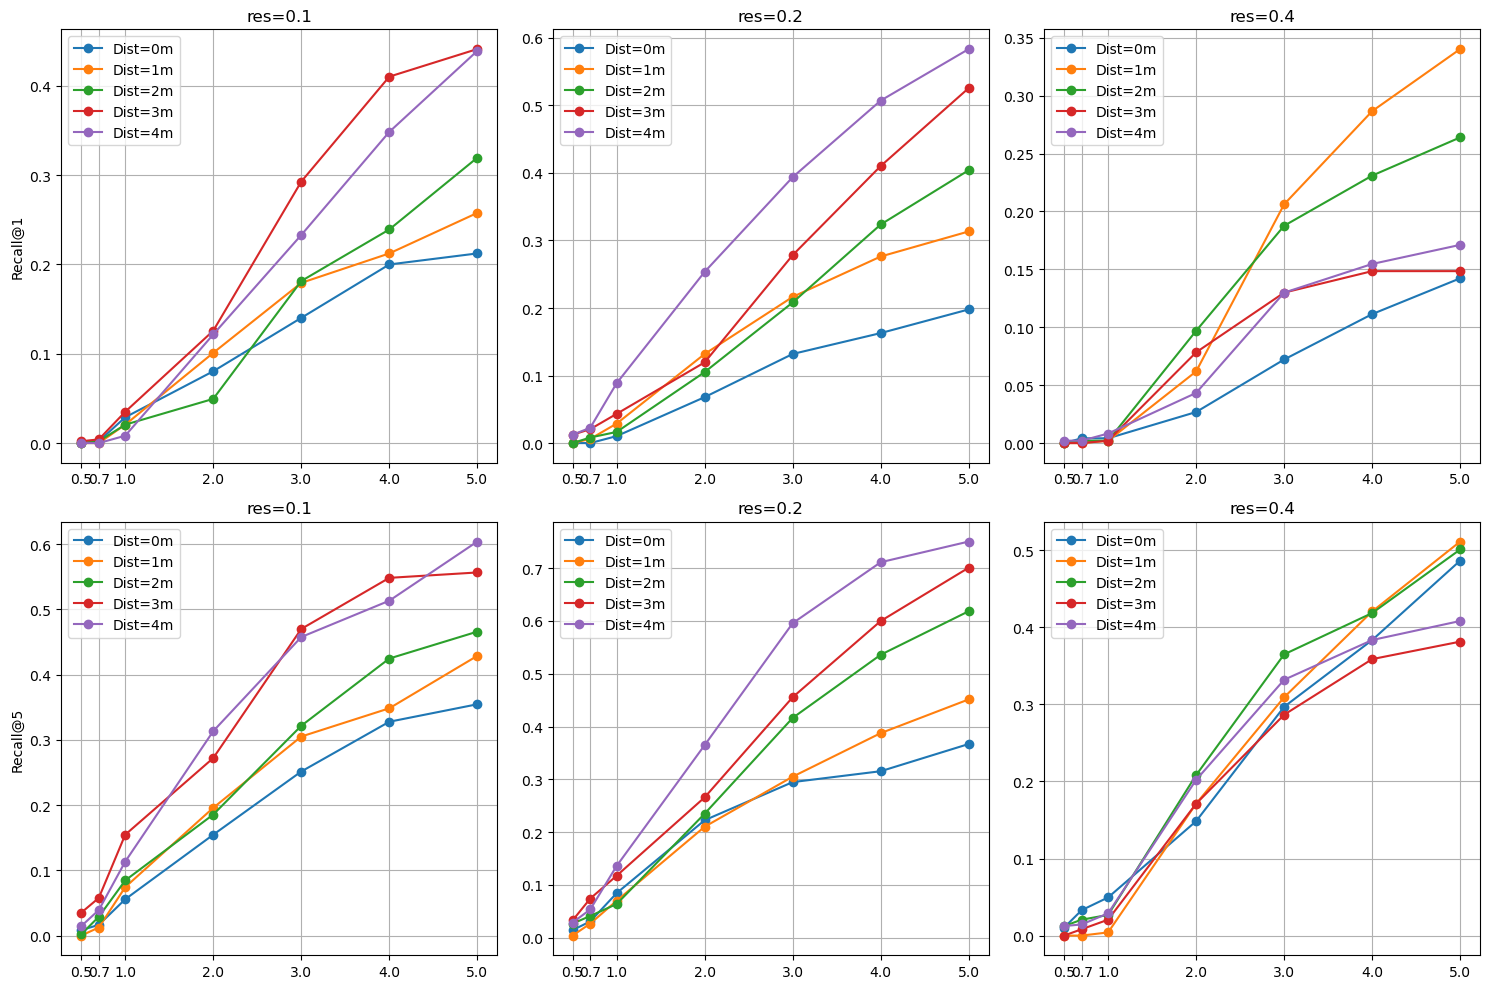

In [84]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for i, title in enumerate(['Recall@1', 'Recall@5']):
    for j, res in enumerate(resolutions):
        for k, diam in enumerate(diameters):
            axs[i, j].plot(gt_list, all_results[k, :, i, j], marker='o', label=f'Dist={diam}m')
            axs[i, j].set_title(f'res={res}')
        if j == 0: axs[i, j].set_ylabel(title)
        axs[i, j].set_xticks(gt_list)
        axs[i, j].legend()
        axs[i, j].grid()

plt.tight_layout()
plt.savefig('recalls_diameters.png')
plt.show()